# Fake News Detection Using CNN

**Student ID:** CIT-24-01-0460  
**Deep Learning Model:** Convolutional Neural Network (CNN)  
**Task:** Fake and Real News Classification

In [1]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import train_test_split

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    Dense,
    Dropout,
    Embedding,
    GlobalMaxPooling1D,
    TextVectorization
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

print("Libraries imported successfully.")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully.
TensorFlow version: 2.21.0


In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Random seeds configured successfully.")

Random seeds configured successfully.


In [3]:
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root  :", PROJECT_ROOT)
print("Data folder   :", DATA_DIR)
print("Models folder :", MODELS_DIR)
print("Reports folder:", REPORTS_DIR)

Project root  : d:\NLP_Group_39
Data folder   : d:\NLP_Group_39\data
Models folder : d:\NLP_Group_39\models
Reports folder: d:\NLP_Group_39\reports


In [4]:
from data_loader import load_news_data
from preprocessing import clean_text

print("Data loading and preprocessing functions imported successfully.")

Data loading and preprocessing functions imported successfully.


In [5]:
dataset = load_news_data()

print("Dataset loaded successfully.")
print("Dataset shape:", dataset.shape)

dataset.head()

Dataset loaded successfully.
Dataset shape: (39103, 6)


,title,text,subject,date,label,content
0,First Somali Refugee Elected In American Hist...,"On November 8, 2016, Ilhan Omar made history a...",News,"December 8, 2016",0,First Somali Refugee Elected In American Histo...
1,MY LAST VIDEO EVER?…Paul Joseph Watson Explain...,This video should rock every advocate of free...,politics,"Mar 24, 2017",0,MY LAST VIDEO EVER?…Paul Joseph Watson Explain...
2,GOP Third-Party Candidate Live-Tweets Trump’s...,It s only been a few weeks since CIA veteran E...,News,"August 15, 2016",0,GOP Third-Party Candidate Live-Tweets Trump’s ...
3,BREAKING NEWS: Woman Who Narrated BRUTAL TORTU...,When four Chicago thugs videotaped the brutal ...,politics,"Dec 9, 2017",0,BREAKING NEWS: Woman Who Narrated BRUTAL TORTU...
4,Iran warns U.S. against imposing further sanct...,BEIRUT/DUBAI (Reuters) - Iran warned the Unite...,worldnews,"October 8, 2017",1,Iran warns U.S. against imposing further sanct...


In [6]:
print("Dataset columns:")
print(dataset.columns.tolist())

print("\nMissing values:")
print(dataset.isnull().sum())

print("\nClass distribution:")
print(dataset["label"].value_counts().sort_index())

print("\nLabel mapping:")
print("0 = Fake News")
print("1 = Real News")

Dataset columns:
['title', 'text', 'subject', 'date', 'label', 'content']

Missing values:
title      0
text       0
subject    0
date       0
label      0
content    0
dtype: int64

Class distribution:
label
0    17907
1    21196
Name: count, dtype: int64

Label mapping:
0 = Fake News
1 = Real News


## Data Preprocessing

The news articles are cleaned by converting text to lowercase and removing URLs, email addresses, HTML tags, numbers, punctuation marks, special characters, and unnecessary spaces.

In [7]:
cnn_dataset = dataset.copy()

print("Starting text preprocessing...")

cnn_dataset["clean_content"] = (
    cnn_dataset["content"]
    .astype(str)
    .apply(clean_text)
)

# Remove empty articles after cleaning
cnn_dataset = cnn_dataset[
    cnn_dataset["clean_content"].str.strip() != ""
].copy()

cnn_dataset = cnn_dataset.reset_index(drop=True)

print("Text preprocessing completed.")
print("Original dataset shape:", dataset.shape)
print("Cleaned dataset shape :", cnn_dataset.shape)

print("\nMissing values after preprocessing:")
print(
    cnn_dataset[
        ["content", "clean_content", "label"]
    ].isnull().sum()
)

Starting text preprocessing...
Text preprocessing completed.
Original dataset shape: (39103, 6)
Cleaned dataset shape : (39098, 7)

Missing values after preprocessing:
content          0
clean_content    0
label            0
dtype: int64


In [8]:
sample_original_text = cnn_dataset.loc[0, "content"]
sample_cleaned_text = cnn_dataset.loc[0, "clean_content"]

print("Original text:")
print(sample_original_text[:500])

print("\nCleaned text:")
print(sample_cleaned_text[:500])

Original text:
First Somali Refugee Elected In American History Subjected To Islamophobic Attack On November 8, 2016, Ilhan Omar made history as being the first Somali-American to be elected to any position in America. Hailing from the progressive state of Minnesota, Omar will serve in the state House of Representatives from the 60B district. Running on the Democratic-Farmer-Labor Party, Omar supports progressive causes championed by Hillary Clinton and Bernie Sanders, Omar won with 81 percent of the vote.The 

Cleaned text:
first somali refugee elected in american history subjected to islamophobic attack on november ilhan omar made history as being the first somali american to be elected to any position in america hailing from the progressive state of minnesota omar will serve in the state house of representatives from the b district running on the democratic farmer labor party omar supports progressive causes championed by hillary clinton and bernie sanders omar won with percent of t

## Exploratory Data Analysis

This section analyzes the class distribution and article length patterns before developing the CNN model.

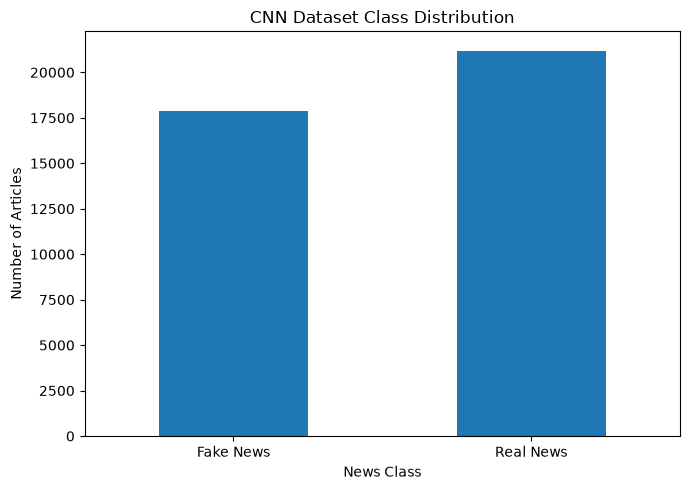

CNN class distribution:
label
0    17902
1    21196
Name: count, dtype: int64

Chart saved to:
d:\NLP_Group_39\reports\cnn_class_distribution.png


In [9]:
cnn_class_distribution = (
    cnn_dataset["label"]
    .value_counts()
    .sort_index()
)

class_names = cnn_class_distribution.rename(
    index={
        0: "Fake News",
        1: "Real News"
    }
)

class_names.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("CNN Dataset Class Distribution")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.tight_layout()

cnn_class_chart_path = (
    REPORTS_DIR
    / "cnn_class_distribution.png"
)

plt.savefig(
    cnn_class_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("CNN class distribution:")
print(cnn_class_distribution)

print("\nChart saved to:")
print(cnn_class_chart_path)

In [10]:
cnn_dataset["word_count"] = (
    cnn_dataset["clean_content"]
    .str.split()
    .str.len()
)

article_length_summary = (
    cnn_dataset
    .groupby("label")["word_count"]
    .describe()
)

print("Article length summary:")
display(article_length_summary)

Article length summary:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17902.0,435.195676,361.337814,3.0,284.0,392.0,521.0,8295.0
1,21196.0,397.829968,276.649016,4.0,158.0,371.0,536.0,5254.0


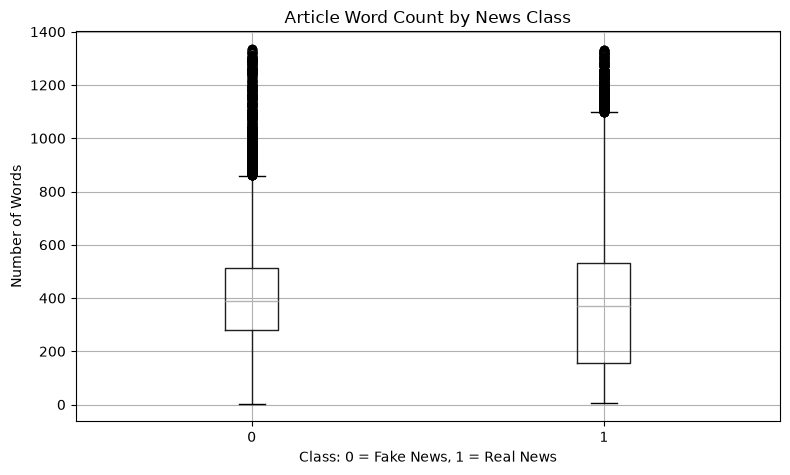

Chart saved to:
d:\NLP_Group_39\reports\cnn_article_length_distribution.png


In [11]:
maximum_display_length = (
    cnn_dataset["word_count"].quantile(0.99)
)

length_plot_data = cnn_dataset[
    cnn_dataset["word_count"] <= maximum_display_length
].copy()

length_plot_data.boxplot(
    column="word_count",
    by="label",
    figsize=(8, 5)
)

plt.suptitle("")
plt.title("Article Word Count by News Class")
plt.xlabel("Class: 0 = Fake News, 1 = Real News")
plt.ylabel("Number of Words")
plt.tight_layout()

cnn_length_chart_path = (
    REPORTS_DIR
    / "cnn_article_length_distribution.png"
)

plt.savefig(
    cnn_length_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved to:")
print(cnn_length_chart_path)

In [12]:
X = cnn_dataset["clean_content"].astype(str)
y = cnn_dataset["label"].astype(int)

print("Number of news articles:", len(X))
print("Number of labels       :", len(y))

print("\nTarget class distribution:")
print(y.value_counts().sort_index())

Number of news articles: 39098
Number of labels       : 39098

Target class distribution:
label
0    17902
1    21196
Name: count, dtype: int64


In [13]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print("Dataset splitting completed successfully.")

print("\nTraining records  :", len(X_train))
print("Validation records:", len(X_validation))
print("Testing records   :", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nValidation class distribution:")
print(y_validation.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Dataset splitting completed successfully.

Training records  : 28150
Validation records: 3128
Testing records   : 7820

Training class distribution:
label
0    12889
1    15261
Name: count, dtype: int64

Validation class distribution:
label
0    1432
1    1696
Name: count, dtype: int64

Testing class distribution:
label
0    3581
1    4239
Name: count, dtype: int64


## Word Frequency Analysis

This section identifies the most frequently occurring words in fake and real news articles after text preprocessing.

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

print("CountVectorizer imported successfully.")

CountVectorizer imported successfully.


In [15]:
def get_top_words(text_data, number_of_words=15):
    sample_size = min(5000, len(text_data))

    sampled_text = text_data.sample(
        n=sample_size,
        random_state=RANDOM_STATE
    )

    vectorizer = CountVectorizer(
        stop_words="english",
        max_features=5000
    )

    word_matrix = vectorizer.fit_transform(
        sampled_text.astype(str)
    )

    word_frequencies = word_matrix.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()

    frequency_table = pd.DataFrame(
        {
            "Word": words,
            "Frequency": word_frequencies
        }
    )

    return (
        frequency_table
        .sort_values("Frequency", ascending=False)
        .head(number_of_words)
        .reset_index(drop=True)
    )


print("Top-word function created successfully.")

Top-word function created successfully.


In [16]:
fake_top_words = get_top_words(
    cnn_dataset.loc[
        cnn_dataset["label"] == 0,
        "clean_content"
    ]
)

print("Most Frequent Words in Fake News:")
display(fake_top_words)

Most Frequent Words in Fake News:


,Word,Frequency
0,trump,20743
1,said,7004
2,people,5891
3,president,5887
4,just,5004
5,obama,4462
6,donald,4412
7,clinton,4215
8,like,4126
9,video,3569


In [17]:
real_top_words = get_top_words(
    cnn_dataset.loc[
        cnn_dataset["label"] == 1,
        "clean_content"
    ]
)

print("Most Frequent Words in Real News:")
display(real_top_words)

Most Frequent Words in Real News:


,Word,Frequency
0,said,23014
1,trump,13707
2,reuters,6715
3,president,6675
4,state,5087
5,government,4412
6,house,4350
7,new,4183
8,states,3982
9,republican,3949


## Feature Representation Using Text Vectorization and Word Embeddings

The TextVectorization layer converts cleaned news articles into integer sequences. The Embedding layer converts each word index into a dense numerical vector that can be processed by the CNN.

In [18]:
MAX_VOCABULARY_SIZE = 30000
MAX_SEQUENCE_LENGTH = 500
EMBEDDING_DIMENSION = 128
BATCH_SIZE = 64
EPOCHS = 10

print("CNN configuration:")
print("Maximum vocabulary size :", MAX_VOCABULARY_SIZE)
print("Maximum sequence length :", MAX_SEQUENCE_LENGTH)
print("Embedding dimension     :", EMBEDDING_DIMENSION)
print("Batch size              :", BATCH_SIZE)
print("Maximum epochs          :", EPOCHS)

CNN configuration:
Maximum vocabulary size : 30000
Maximum sequence length : 500
Embedding dimension     : 128
Batch size              : 64
Maximum epochs          : 10


In [19]:
text_vectorizer = TextVectorization(
    max_tokens=MAX_VOCABULARY_SIZE,
    output_mode="int",
    output_sequence_length=MAX_SEQUENCE_LENGTH
)

print("TextVectorization layer created successfully.")

TextVectorization layer created successfully.


In [20]:
print("Vocabulary adaptation started...")

text_vectorizer.adapt(
    X_train.to_numpy()
)

vocabulary = text_vectorizer.get_vocabulary()
vocabulary_size = len(vocabulary)

print("Vocabulary adaptation completed.")
print("Actual vocabulary size:", vocabulary_size)

print("\nFirst 20 vocabulary items:")
print(vocabulary[:20])

Vocabulary adaptation started...
Vocabulary adaptation completed.
Actual vocabulary size: 30000

First 20 vocabulary items:
['', '[UNK]', np.str_('the'), np.str_('to'), np.str_('of'), np.str_('a'), np.str_('and'), np.str_('in'), np.str_('s'), np.str_('that'), np.str_('on'), np.str_('for'), np.str_('is'), np.str_('trump'), np.str_('said'), np.str_('he'), np.str_('it'), np.str_('with'), np.str_('was'), np.str_('as')]


In [21]:
sample_article = X_train.iloc[0]

sample_sequence = text_vectorizer(
    tf.constant([sample_article])
)

print("Original cleaned article:")
print(sample_article[:500])

print("\nVectorized sequence shape:")
print(sample_sequence.shape)

print("\nFirst 50 token IDs:")
print(sample_sequence.numpy()[0][:50])

Original cleaned article:
chilean economic officials resign in blow to center left coalition santiago reuters chilean president michelle bachelet s top economic officials resigned on thursday after the cancellation of a major mining project weakening her center left coalition before november elections finance minister rodrigo valdes said in a news conference some members of bachelet s government had not shared his sense of urgency to spur growth and attract investment to the world s top copper producer i wasn t able to m

Vectorized sequence shape:
(1, 500)

First 50 token IDs:
[14211   373   164  2062     7  2209     3   530   250   532  9045    59
 14211    38  2108 11520     8   257   373   164  2304    10   198    48
     2  9232     4     5   342  2909  1128  7179    58   530   250   532
   117   492   573  1204   196  5386 26758    14     7     5   103   515
    83   258]


## CNN Model Development

The CNN model uses an Embedding layer to represent words as dense numerical vectors. The Conv1D layer identifies important local patterns and phrases, while GlobalMaxPooling1D selects the strongest features for fake and real news classification.

In [22]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        X_train.astype(str).to_numpy(),
        y_train.to_numpy()
    )
)

validation_dataset = tf.data.Dataset.from_tensor_slices(
    (
        X_validation.astype(str).to_numpy(),
        y_validation.to_numpy()
    )
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        X_test.astype(str).to_numpy(),
        y_test.to_numpy()
    )
)

train_dataset = (
    train_dataset
    .shuffle(
        buffer_size=len(X_train),
        seed=RANDOM_STATE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

validation_dataset = (
    validation_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [23]:
cnn_model = tf.keras.Sequential(
    [
        tf.keras.Input(
            shape=(),
            dtype=tf.string,
            name="news_text"
        ),

        text_vectorizer,

        tf.keras.layers.Embedding(
            input_dim=vocabulary_size,
            output_dim=EMBEDDING_DIMENSION,
            name="embedding"
        ),

        tf.keras.layers.Conv1D(
            filters=128,
            kernel_size=5,
            activation="relu",
            name="convolution"
        ),

        tf.keras.layers.GlobalMaxPooling1D(
            name="global_max_pooling"
        ),

        tf.keras.layers.Dense(
            64,
            activation="relu",
            name="dense_hidden"
        ),

        tf.keras.layers.Dropout(
            0.5,
            name="dropout"
        ),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid",
            name="output"
        )
    ]
)

print("CNN model created successfully.")

CNN model created successfully.


In [24]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        ),
        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

print("CNN model compiled successfully.")

CNN model compiled successfully.


In [25]:
cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 500)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 500, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convolution (Conv1D)            │ (None, 496, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling              │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,930,369 (14.99 MB)

 Trainable params: 3,930,369 (14.99 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
cnn_best_model_path = (
    MODELS_DIR
    / "cnn_best_model.keras"
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(cnn_best_model_path),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_learning_rate = (
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=0.00001,
        verbose=1
    )
)

print("Training callbacks configured successfully.")
print("Best model path:", cnn_best_model_path)

Training callbacks configured successfully.
Best model path: d:\NLP_Group_39\models\cnn_best_model.keras


In [27]:
print("CNN model training started...")

cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        model_checkpoint,
        reduce_learning_rate
    ],
    verbose=1
)

print("CNN model training completed successfully.")

CNN model training started...
Epoch 1/10


d:\NLP_Group_39\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


440/440 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9661 - auc: 0.9964 - loss: 0.0795 - precision: 0.9449 - recall: 0.9955
Epoch 1: val_loss improved from None to 0.00636, saving model to d:\NLP_Group_39\models\cnn_best_model.keras

Epoch 1: finished saving model to d:\NLP_Group_39\models\cnn_best_model.keras
440/440 ━━━━━━━━━━━━━━━━━━━━ 79s 159ms/step - accuracy: 0.9661 - auc: 0.9964 - loss: 0.0795 - precision: 0.9449 - recall: 0.9955 - val_accuracy: 0.9981 - val_auc: 1.0000 - val_loss: 0.0064 - val_precision: 0.9976 - val_recall: 0.9988 - learning_rate: 0.0010
Epoch 2/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9986 - auc: 0.9998 - loss: 0.0056 - precision: 0.9988 - recall: 0.9986
Epoch 2: val_loss did not improve from 0.00636

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
440/440 ━━━━━━━━━━━━━━━━━━━━ 77s 174ms/step - accuracy: 0.9986 - auc: 0.9998 - loss: 0.0056 - precision: 0.9988 - recall: 0.9986 - val_accuracy: 0.9981 - val_auc: 

## CNN Training History

The following graphs compare training and validation accuracy and loss across epochs. These graphs help identify whether the model is learning effectively or overfitting.

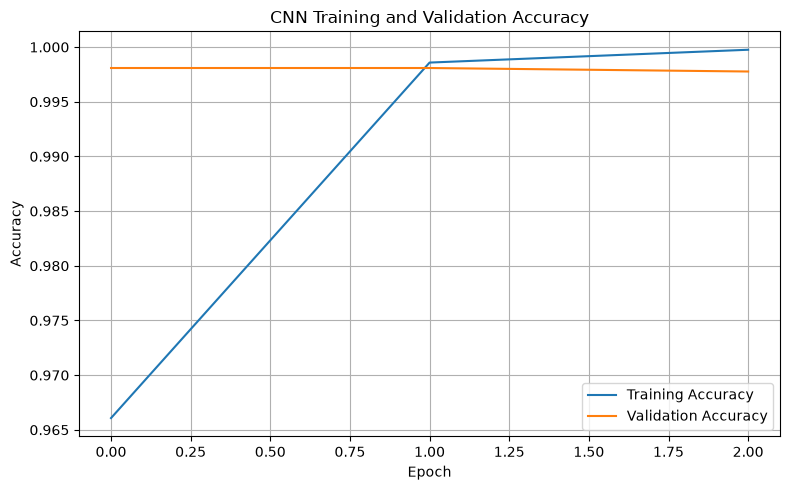

Accuracy graph saved to:
d:\NLP_Group_39\reports\cnn_training_accuracy.png


In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.tight_layout()

cnn_accuracy_graph_path = (
    REPORTS_DIR
    / "cnn_training_accuracy.png"
)

plt.savefig(
    cnn_accuracy_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Accuracy graph saved to:")
print(cnn_accuracy_graph_path)

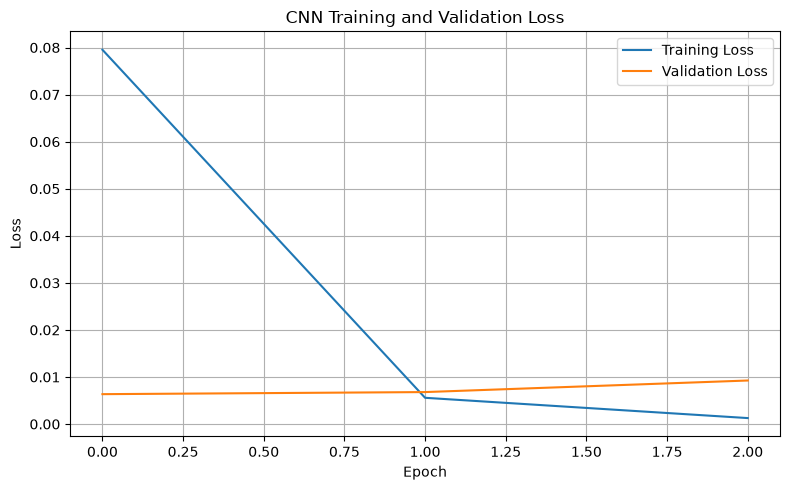

Loss graph saved to:
d:\NLP_Group_39\reports\cnn_training_loss.png


In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.tight_layout()

cnn_loss_graph_path = (
    REPORTS_DIR
    / "cnn_training_loss.png"
)

plt.savefig(
    cnn_loss_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Loss graph saved to:")
print(cnn_loss_graph_path)

## CNN Model Evaluation

The best saved CNN model is evaluated using the unseen test dataset. Accuracy, precision, recall, F1-score, ROC-AUC, classification report, and confusion matrix are used to measure performance.

In [31]:
best_cnn_model = tf.keras.models.load_model(
    cnn_best_model_path
)

print("Best CNN model loaded successfully.")
print("Model path:", cnn_best_model_path)

Best CNN model loaded successfully.
Model path: d:\NLP_Group_39\models\cnn_best_model.keras


In [32]:
test_evaluation = best_cnn_model.evaluate(
    test_dataset,
    return_dict=True,
    verbose=1
)

print("\nCNN Test Evaluation Results")
print("=" * 45)

for metric_name, metric_value in test_evaluation.items():
    print(
        f"{metric_name.capitalize():10s}: "
        f"{metric_value:.4f}"
    )

123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9968 - auc: 0.9996 - loss: 0.0126 - precision: 0.9969 - recall: 0.9972

CNN Test Evaluation Results
Accuracy  : 0.9968
Auc       : 0.9996
Loss      : 0.0126
Precision : 0.9969
Recall    : 0.9972


In [33]:
print("Generating CNN predictions...")

y_probability = (
    best_cnn_model.predict(
        test_dataset,
        verbose=1
    )
    .reshape(-1)
)

y_pred = (
    y_probability >= 0.50
).astype(int)

print("Predictions generated successfully.")

print("\nFirst 10 probabilities:")
print(y_probability[:10])

print("\nFirst 10 predicted labels:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_test.iloc[:10].to_numpy())

Generating CNN predictions...
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step
Predictions generated successfully.

First 10 probabilities:
[9.9991292e-01 1.5774541e-08 9.9974948e-01 9.9966502e-01 6.9250361e-10
 9.9987072e-01 9.9996459e-01 1.6906762e-09 9.9956727e-01 9.9490935e-01]

First 10 predicted labels:
[1 0 1 1 0 1 1 0 1 1]

First 10 actual labels:
[1 0 1 1 0 1 1 0 1 1]


In [34]:
cnn_accuracy = accuracy_score(
    y_test,
    y_pred
)

cnn_precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

cnn_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

cnn_f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

cnn_roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("CNN Evaluation Results")
print("=" * 45)

print(f"Accuracy  : {cnn_accuracy:.4f}")
print(f"Precision : {cnn_precision:.4f}")
print(f"Recall    : {cnn_recall:.4f}")
print(f"F1-Score  : {cnn_f1:.4f}")
print(f"ROC-AUC   : {cnn_roc_auc:.4f}")

CNN Evaluation Results
Accuracy  : 0.9968
Precision : 0.9969
Recall    : 0.9972
F1-Score  : 0.9971
ROC-AUC   : 0.9999


In [35]:
cnn_classification_report = classification_report(
    y_test,
    y_pred,
    target_names=[
        "Fake News",
        "Real News"
    ],
    zero_division=0
)

print("CNN Classification Report")
print("=" * 55)
print(cnn_classification_report)

CNN Classification Report
              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00      3581
   Real News       1.00      1.00      1.00      4239

    accuracy                           1.00      7820
   macro avg       1.00      1.00      1.00      7820
weighted avg       1.00      1.00      1.00      7820



## CNN Confusion Matrix

The confusion matrix displays correctly and incorrectly classified fake and real news articles.

In [36]:
cnn_confusion_values = confusion_matrix(
    y_test,
    y_pred
)

print("CNN Confusion Matrix:")
print(cnn_confusion_values)

true_fake = cnn_confusion_values[0, 0]
false_real = cnn_confusion_values[0, 1]
false_fake = cnn_confusion_values[1, 0]
true_real = cnn_confusion_values[1, 1]

print("\nConfusion Matrix Explanation")
print("=" * 45)

print(
    "Fake news correctly predicted as Fake :",
    true_fake
)

print(
    "Fake news incorrectly predicted as Real:",
    false_real
)

print(
    "Real news incorrectly predicted as Fake:",
    false_fake
)

print(
    "Real news correctly predicted as Real  :",
    true_real
)

CNN Confusion Matrix:
[[3568   13]
 [  12 4227]]

Confusion Matrix Explanation
Fake news correctly predicted as Fake : 3568
Fake news incorrectly predicted as Real: 13
Real news incorrectly predicted as Fake: 12
Real news correctly predicted as Real  : 4227


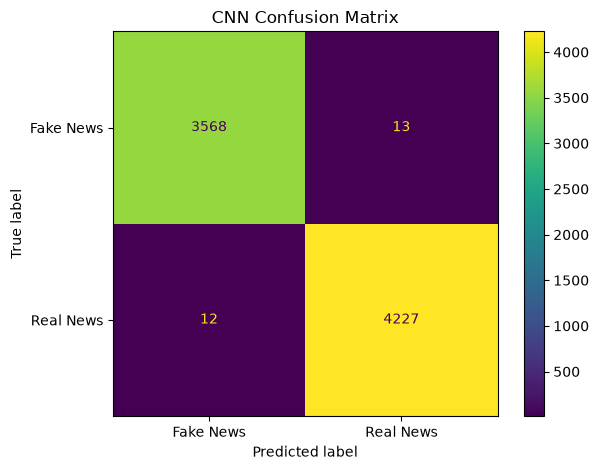

Confusion matrix saved to:
d:\NLP_Group_39\reports\cnn_confusion_matrix.png


In [37]:
cnn_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=cnn_confusion_values,
    display_labels=[
        "Fake News",
        "Real News"
    ]
)

cnn_matrix_display.plot(
    values_format="d"
)

plt.title("CNN Confusion Matrix")
plt.tight_layout()

cnn_confusion_matrix_path = (
    REPORTS_DIR
    / "cnn_confusion_matrix.png"
)

plt.savefig(
    cnn_confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:")
print(cnn_confusion_matrix_path)

## CNN ROC Curve

The ROC curve evaluates the CNN model at different classification thresholds. A ROC-AUC value closer to 1 indicates stronger classification performance.

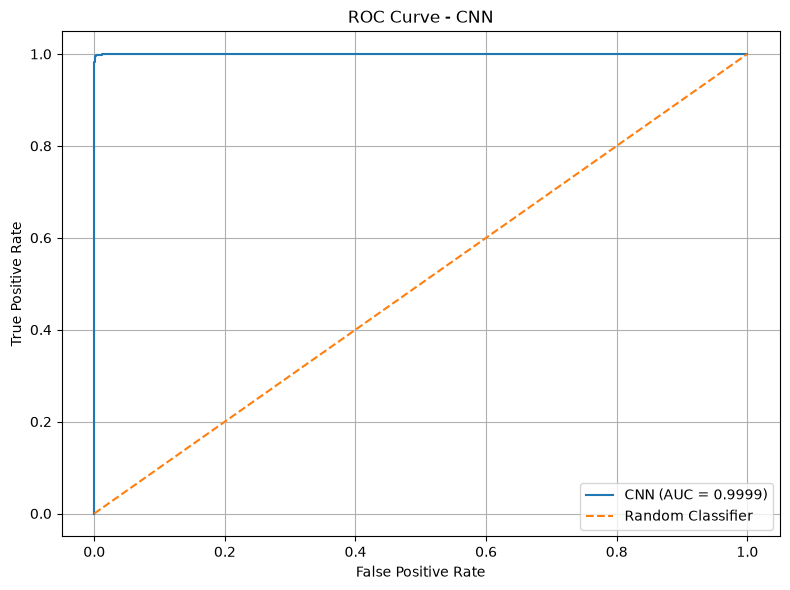

ROC curve saved to:
d:\NLP_Group_39\reports\cnn_roc_curve.png


In [38]:
cnn_false_positive_rate, cnn_true_positive_rate, thresholds = (
    roc_curve(
        y_test,
        y_probability
    )
)

plt.figure(figsize=(8, 6))

plt.plot(
    cnn_false_positive_rate,
    cnn_true_positive_rate,
    label=f"CNN (AUC = {cnn_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - CNN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.tight_layout()

cnn_roc_curve_path = (
    REPORTS_DIR
    / "cnn_roc_curve.png"
)

plt.savefig(
    cnn_roc_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved to:")
print(cnn_roc_curve_path)

In [39]:
cnn_metrics_dataframe = pd.DataFrame(
    {
        "Model": ["CNN"],
        "Accuracy": [cnn_accuracy],
        "Precision": [cnn_precision],
        "Recall": [cnn_recall],
        "F1-Score": [cnn_f1],
        "ROC-AUC": [cnn_roc_auc]
    }
)

cnn_metrics_path = (
    REPORTS_DIR
    / "cnn_metrics.csv"
)

cnn_metrics_dataframe.to_csv(
    cnn_metrics_path,
    index=False
)

print("CNN evaluation metrics saved successfully.")

display(cnn_metrics_dataframe)

print("\nMetrics file:")
print(cnn_metrics_path)

CNN evaluation metrics saved successfully.


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,CNN,0.996803,0.996934,0.997169,0.997052,0.999908



Metrics file:
d:\NLP_Group_39\reports\cnn_metrics.csv


In [40]:
cnn_prediction_results = pd.DataFrame(
    {
        "News_Text": X_test.to_numpy(),
        "Actual_Label": y_test.to_numpy(),
        "Predicted_Label": y_pred,
        "Real_News_Probability": y_probability,
        "Fake_News_Probability": (
            1 - y_probability
        )
    }
)

cnn_predictions_path = (
    REPORTS_DIR
    / "cnn_test_predictions.csv"
)

cnn_prediction_results.to_csv(
    cnn_predictions_path,
    index=False
)

print("CNN test predictions saved successfully.")
print(
    "Number of saved predictions:",
    len(cnn_prediction_results)
)

display(cnn_prediction_results.head())

print("\nPredictions file:")
print(cnn_predictions_path)

CNN test predictions saved successfully.
Number of saved predictions: 7820


,News_Text,Actual_Label,Predicted_Label,Real_News_Probability,Fake_News_Probability
0,factbox conservative liberal progressive merke...,1,1,9.999129e-01,0.000087
1,watch students walk out during mike pence s co...,0,0,1.577454e-08,1.000000
2,trumps says expects republican nominee romney ...,1,1,9.997495e-01,0.000251
3,u s backed by china proposes tough n korea san...,1,1,9.996650e-01,0.000335
4,nra board member ted nugent just encouraged hi...,0,0,6.925036e-10,1.000000



Predictions file:
d:\NLP_Group_39\reports\cnn_test_predictions.csv
